In [1]:
# ============================================
# CELL 1: Setup environment
# - Install TensorFlow versi stabil (2.19.0)
# - Import library utama
# - Cek GPU
# - Set seed agar hasil lebih konsisten (reproducible)
# ============================================

!pip -q install -U "tensorflow==2.19.0"

import os, time, random, tempfile
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import uuid

SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
!nvidia-smi -L

ERROR: Could not find a version that satisfies the requirement tensorflow==2.19.0 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.19.0


TF version: 2.19.0
GPU devices: []
GPU 0: NVIDIA GeForce RTX 3050 Laptop GPU (UUID: GPU-d06c3f01-161f-79eb-6a14-2397a560deb2)


In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [3]:
# ============================================
# CELL 2: Mount Drive & set path dataset
# - Menghubungkan Google Drive
# - Set folder dataset split ala paper (dataset_ready_paper)
# ============================================

DATASET_DIR = r"E:\DATASET\Tomato_Resize"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

In [4]:
# ============================================
# CELL 3: Verifikasi split dataset
# - Mengecek jumlah file per kelas di train/val/test
# ============================================

def count_files_in_subdirs(base_dir):
    counts = {}
    if not os.path.exists(base_dir):
        print(f"Warning: Directory not found: {base_dir}")
        return counts

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            num_files = len(os.listdir(class_path))
            counts[class_name] = num_files
    return counts

print("Verifying dataset split...")

print("\nTrain set counts:")
train_counts = count_files_in_subdirs(TRAIN_DIR)
if train_counts:
    for class_name, count in train_counts.items():
        print(f"  {class_name}: {count} files")
else:
    print("  No classes found or directory is empty.")

print("\nValidation set counts:")
val_counts = count_files_in_subdirs(VAL_DIR)
if val_counts:
    for class_name, count in val_counts.items():
        print(f"  {class_name}: {count} files")
else:
    print("  No classes found or directory is empty.")

print("\nTest set counts:")
test_counts = count_files_in_subdirs(TEST_DIR)
if test_counts:
    for class_name, count in test_counts.items():
        print(f"  {class_name}: {count} files")
else:
    print("  No classes found or directory is empty.")

print("\nDataset split verification complete.")

Verifying dataset split...

Train set counts:
  Tomato___Bacterial_spot: 901 files
  Tomato___Early_blight: 901 files
  Tomato___healthy: 900 files
  Tomato___Late_blight: 900 files
  Tomato___Leaf_Mold: 903 files
  Tomato___Septoria_leaf_spot: 901 files
  Tomato___Spider_mites Two-spotted_spider_mite: 900 files
  Tomato___Target_Spot: 900 files
  Tomato___Tomato_mosaic_virus: 900 files
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 900 files

Validation set counts:
  Tomato___Bacterial_spot: 100 files
  Tomato___Early_blight: 100 files
  Tomato___healthy: 100 files
  Tomato___Late_blight: 100 files
  Tomato___Leaf_Mold: 100 files
  Tomato___Septoria_leaf_spot: 100 files
  Tomato___Spider_mites Two-spotted_spider_mite: 101 files
  Tomato___Target_Spot: 100 files
  Tomato___Tomato_mosaic_virus: 100 files
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100 files

Test set counts:
  Tomato___Bacterial_spot: 100 files
  Tomato___Early_blight: 100 files
  Tomato___healthy: 100 files
  Tomato___Late_bl

In [5]:
# ============================================
# CELL 4: Load dataset dengan tf.data
# - Membaca gambar dari folder train/val/test
# - Normalisasi TIDAK dilakukan di sini,
# karena akan dilakukan di dalam model via preprocess_input
# ============================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 10
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print("Class order:", class_names)

# Prefetch agar loading lebih cepat
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 9006 files belonging to 10 classes.
Found 1001 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.
Class order: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [6]:
# ============================================
# CELL 5: Konfigurasi training (FE + FT)
# - Stage 1 = Fixed Feature (freeze backbone)
# - Stage 2 = Fine-tuning (unfreeze last N layer)
# - Regularisasi + callbacks
# ============================================

# ---------- STAGE 1 (Fixed Feature) ----------
EPOCHS_STAGE1 = 15
LR_STAGE1 = 1e-3

# ---------- STAGE 2 (Fine-tuning) ----------
EPOCHS_STAGE2 = 10
# LR_STAGE2 akan di-set per varian (FT10/FT20/FT30)

DROPOUT_RATE = 0.4

metrics = [
    tf.keras.metrics.CategoricalAccuracy(name="acc")
]

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

loss_fn = tf.keras.losses.CategoricalCrossentropy()

print("Config loaded.")
print("Stage1:", EPOCHS_STAGE1, "| LR:", LR_STAGE1)
print("Stage2:", EPOCHS_STAGE2, "| LR: set per variant")
print("Dropout:", DROPOUT_RATE)

Config loaded.
Stage1: 15 | LR: 0.001
Stage2: 10 | LR: set per variant
Dropout: 0.4


In [7]:
# ============================================
# CELL 6: Build model (EfficientNetB0)
# - Head classifier dibuat sama:
# GAP -> Dropout -> Dense(softmax)
# - backbone.trainable=False untuk FE
# ============================================

from tensorflow.keras import layers

def build_efficientnetb0():
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="input")

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,)
    )
    backbone.trainable = False  # FE: freeze dari awal

    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = backbone(x, training=False)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(DROPOUT_RATE, seed=SEED, name="dropout")(x)
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax",
        name="classifier"
    )(x)

    model = tf.keras.Model(inputs, outputs, name="efficientnetb0_model")
    return model, backbone

In [8]:
# ============================================
# CELL 7: Utils evaluasi (test, model size, inference, confusion)
# ============================================

from sklearn.metrics import classification_report, confusion_matrix

def get_model_size_mb(model, filename="temp_model.keras"):

    # save model
    model.save(filename, include_optimizer=False)

    # hitung ukuran
    size_mb = os.path.getsize(filename) / (1024 * 1024)

    # hapus file sementara
    os.remove(filename)

    return size_mb

def eval_model(model):
    y_true, y_pred = [], []
    for x, y in test_ds:
        p = model.predict(x, verbose=0)
        y_true += list(np.argmax(y.numpy(), axis=1))
        y_pred += list(np.argmax(p, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    rep = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        digits=4
    )
    return cm, rep

def inference_ms_per_batch(model, ds, warmup_batches=1, measure_batches=2):
    for x, _ in ds.take(warmup_batches):
        _ = model.predict(x, verbose=0)

    times = []
    for x, _ in ds.take(measure_batches):
        t0 = time.time()
        _ = model.predict(x, verbose=0)
        t1 = time.time()
        times.append((t1 - t0) * 1000)

    return float(np.mean(times)), float(np.std(times))

def make_global_matrix(rep, params, size_mb, inf_mean, inf_std, train_time):
    return pd.DataFrame({
        "Metric": [
            "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1",
            "Params", "Model Size (MB)",
            "Inference Mean (ms/batch)", "Inference Std (ms/batch)",
            "Train Time (s)"
        ],
        "Value": [
            rep["accuracy"],
            rep["macro avg"]["precision"],
            rep["macro avg"]["recall"],
            rep["macro avg"]["f1-score"],
            rep["weighted avg"]["f1-score"],
            params, size_mb, inf_mean, inf_std,
            train_time
        ]
    })

def make_confusion_table(cm):
    return pd.DataFrame(
        cm,
        index=[f"Actual_{c}" for c in class_names],
        columns=[f"Pred_{c}" for c in class_names]
    )

def plot_confusion_matrix_blue(cm, classes, title="Confusion Matrix"):
    plt.figure(figsize=(14,10), dpi=300)

    im = plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=11, fontweight="bold"
            )

    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

In [9]:
# ============================================
# CELL 8: Utils MACs & FLOPs (TF 2.19)
# ============================================

from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_macs_and_flops(model, input_shape=(1, 224, 224, 3)):
    func = tf.function(model).get_concrete_function(
        tf.TensorSpec(input_shape, model.inputs[0].dtype)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(func)

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd="op",
            options=opts
        )

    total_flops = float(flops.total_float_ops)
    total_macs = float(total_flops / 2)
    return total_macs, total_flops

In [10]:
# ============================================
# CELL 9: Plot Training History (Accuracy & Loss)
# ============================================

def plot_history(history, title_prefix=""):
    acc_key = "acc" if "acc" in history else "categorical_accuracy"
    val_acc_key = "val_acc" if "val_acc" in history else "val_categorical_accuracy"

    epochs = range(1, len(history["loss"]) + 1)

    plt.figure(figsize=(14,5))

    # ----- Accuracy -----
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history[acc_key], label="Train Acc")
    plt.plot(epochs, history[val_acc_key], label="Val Acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # ----- Loss -----
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [11]:
# ============================================
# CELL 10: Helper Fine-tuning
# - Membuka (unfreeze) last N layer pada backbone
# - BatchNorm tetap freeze agar training stabil
# ============================================

def set_trainable_last_n(backbone, last_n=10):
    backbone.trainable = True

    # freeze semua dulu
    for layer in backbone.layers:
        layer.trainable = False

    # unfreeze last N (kecuali BatchNorm)
    trainable = 0
    for layer in backbone.layers[-last_n:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True
            trainable += 1

    return trainable

In [12]:
# ============================================
# CELL FE-1: Build model + compile (FE)
# ============================================

ef_model, ef_backbone = build_efficientnetb0()
print("Backbone trainable:", ef_backbone.trainable)
ef_model.summary()

ef_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_STAGE1),
    loss=loss_fn,
    metrics=metrics
)

Backbone trainable: False


Model: "efficientnetb0_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)         │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ classifier (Dense)                   │ (None, 10)                  │          12,810 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [13]:
# ============================================
# CELL FE-2: Train Fixed Feature (FE)
# - Output training akan menampilkan acc, loss, val_acc, val_loss
# ============================================

t0 = time.time()
h_fe = ef_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=1
)
t1 = time.time()

fe_train_time = float(t1 - t0)
fe_hist = h_fe.history

# Simpan bobot terbaik FE (karena restore_best_weights=True)
FE_BEST_WEIGHTS = ef_model.get_weights()

print(f"FE train time (s): {fe_train_time}")
print("FE epochs ran:", len(fe_hist["loss"]))

Epoch 1/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 112s 370ms/step - acc: 0.6449 - loss: 1.1748 - val_acc: 0.8122 - val_loss: 0.6965
Epoch 2/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 95s 336ms/step - acc: 0.8225 - loss: 0.6197 - val_acc: 0.8571 - val_loss: 0.5004
Epoch 3/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 93s 331ms/step - acc: 0.8575 - loss: 0.4930 - val_acc: 0.8721 - val_loss: 0.4213
Epoch 4/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 93s 330ms/step - acc: 0.8769 - loss: 0.4204 - val_acc: 0.8831 - val_loss: 0.3813
Epoch 5/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 93s 331ms/step - acc: 0.8769 - loss: 0.3971 - val_acc: 0.8971 - val_loss: 0.3466
Epoch 6/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 93s 329ms/step - acc: 0.8891 - loss: 0.3600 - val_acc: 0.8951 - val_loss: 0.3250
Epoch 7/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 91s 323ms/step - acc: 0.8914 - loss: 0.3468 - val_acc: 0.9051 - val_loss: 0.3130
Epoch 8/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 92s 327ms/step - acc: 0.9005 - loss: 0.3212 - val_acc: 0.9051 - val_loss: 0.2964
Epoch 9/15
282/282 ━━━━━━━━━━━━

=== GLOBAL METRICS: FE ===


,Metric,Value
0,Accuracy,9.430000e-01
1,Macro Precision,9.438894e-01
2,Macro Recall,9.430000e-01
3,Macro F1,9.427496e-01
4,Weighted F1,9.427496e-01
5,Params,4.062381e+06
6,Model Size (MB),1.640121e+01
7,Inference Mean (ms/batch),3.670703e+02
8,Inference Std (ms/batch),6.341100e+00
9,Train Time (s),1.406411e+03


,Pred_Tomato___Bacterial_spot,Pred_Tomato___Early_blight,Pred_Tomato___Late_blight,Pred_Tomato___Leaf_Mold,Pred_Tomato___Septoria_leaf_spot,Pred_Tomato___Spider_mites Two-spotted_spider_mite,Pred_Tomato___Target_Spot,Pred_Tomato___Tomato_Yellow_Leaf_Curl_Virus,Pred_Tomato___Tomato_mosaic_virus,Pred_Tomato___healthy
Actual_Tomato___Bacterial_spot,98,0,1,0,0,0,1,0,0,0
Actual_Tomato___Early_blight,2,91,1,1,2,0,2,0,0,1
Actual_Tomato___Late_blight,0,4,92,3,1,0,0,0,0,0
Actual_Tomato___Leaf_Mold,0,0,0,97,0,3,0,0,0,0
Actual_Tomato___Septoria_leaf_spot,3,2,1,5,83,0,4,0,2,0
Actual_Tomato___Spider_mites Two-spotted_spider_mite,0,0,0,1,0,94,4,1,0,0
Actual_Tomato___Target_Spot,1,0,0,0,3,3,93,0,0,0
Actual_Tomato___Tomato_Yellow_Leaf_Curl_Virus,3,0,0,0,0,0,0,97,0,0
Actual_Tomato___Tomato_mosaic_virus,0,0,0,1,0,0,0,0,99,0
Actual_Tomato___healthy,0,0,0,0,0,0,1,0,0,99


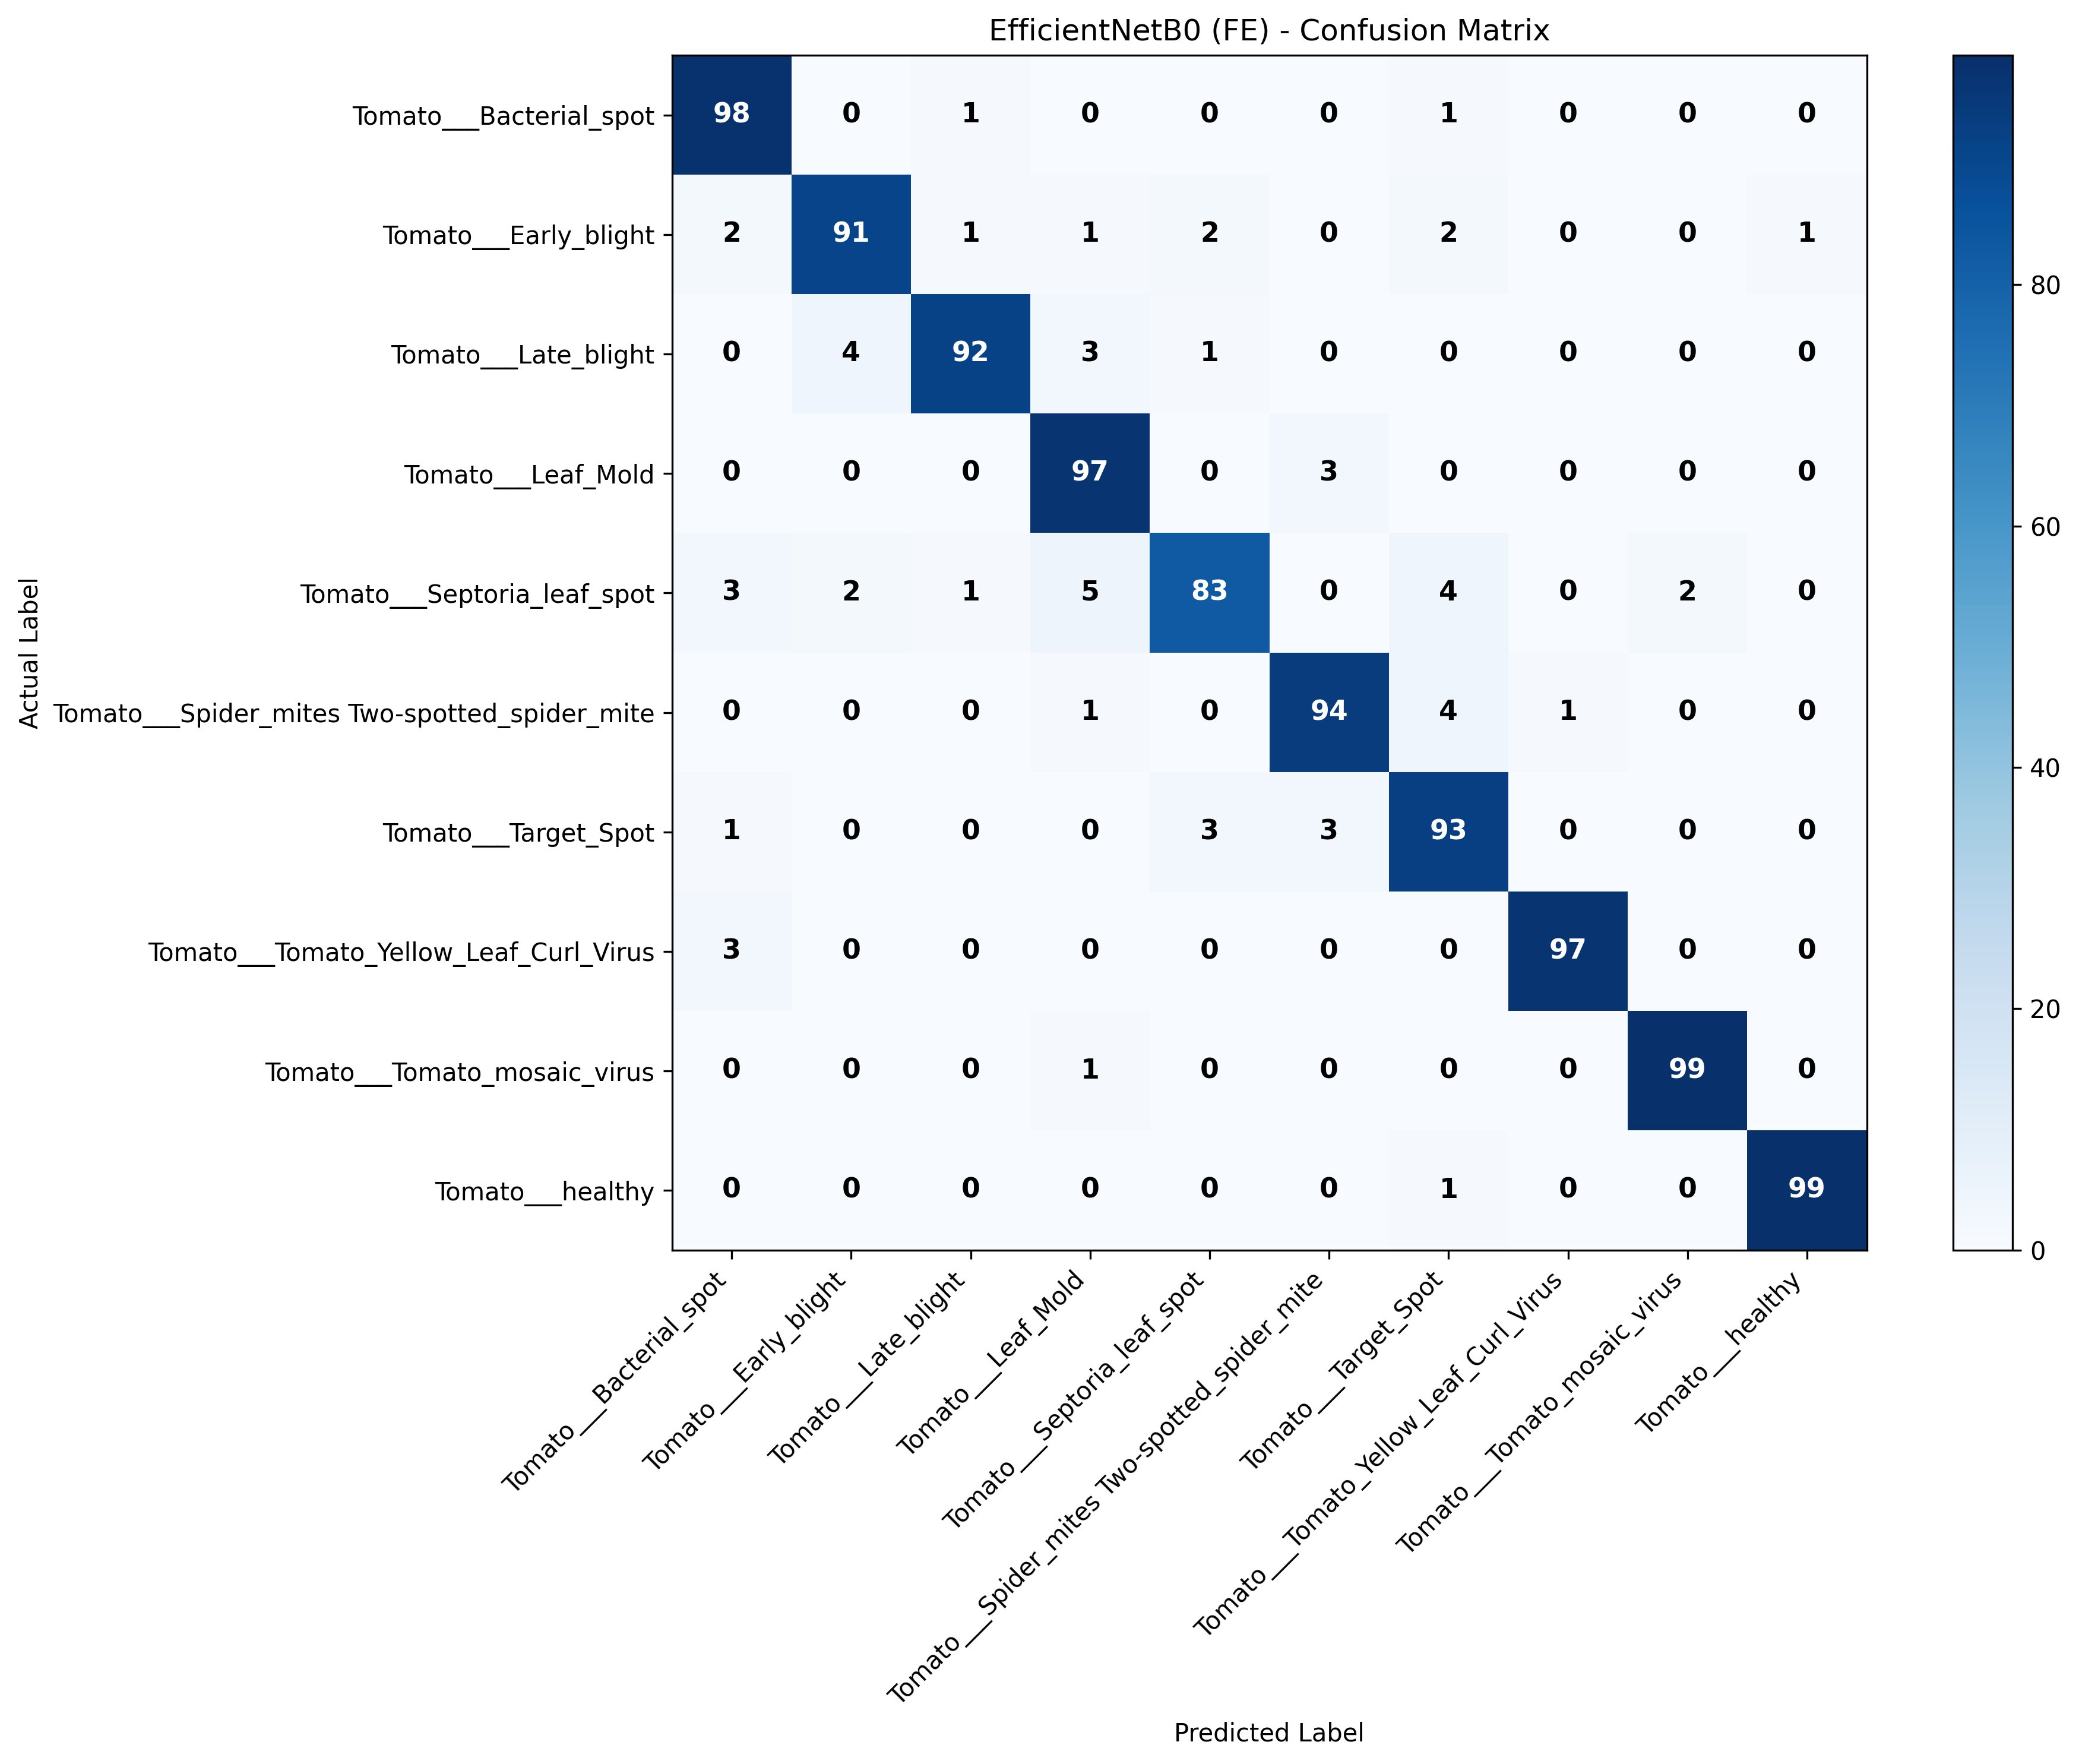

In [14]:
# ============================================
# CELL FE-3: Eval FE (Test set)
# - Global metrics + confusion matrix table + heatmap
# ============================================

fe_cm, fe_rep = eval_model(ef_model)

fe_params = ef_model.count_params()
fe_size_mb = get_model_size_mb(ef_model)
fe_inf_mean, fe_inf_std = inference_ms_per_batch(ef_model, test_ds)

fe_global = make_global_matrix(
    fe_rep, fe_params, fe_size_mb,
    fe_inf_mean, fe_inf_std,
    fe_train_time
)
fe_cm_df = make_confusion_table(fe_cm)

print("=== GLOBAL METRICS: FE ===")
display(fe_global)
display(fe_cm_df)

plot_confusion_matrix_blue(fe_cm, class_names, "EfficientNetB0 (FE) - Confusion Matrix")

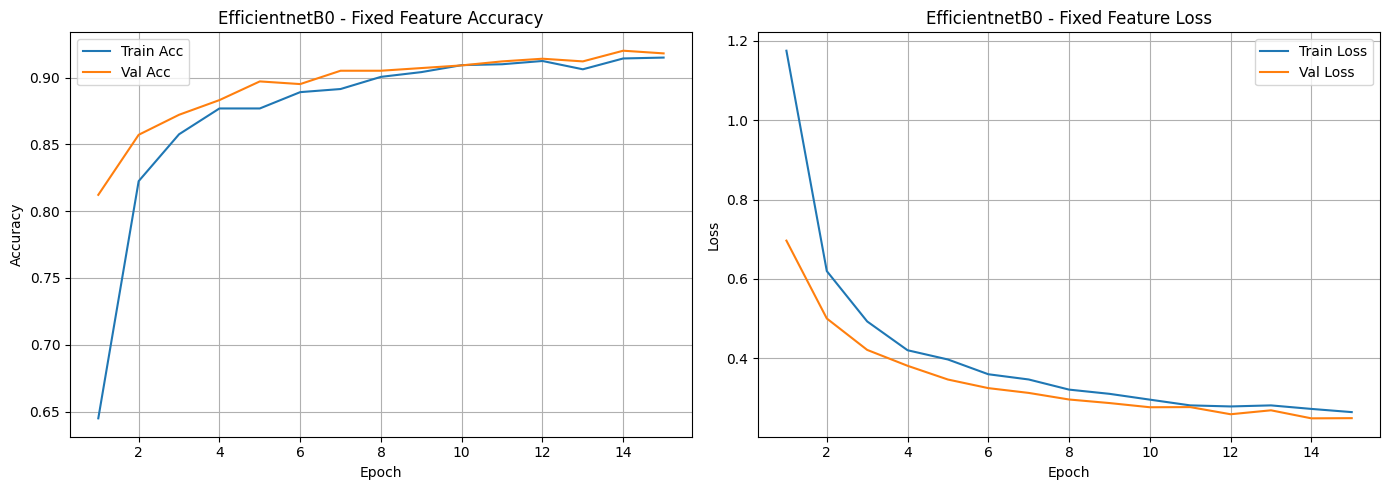

In [15]:
# ============================================
# CELL FE-PLOT: Accuracy & Loss (Fixed Feature)
# ============================================

plot_history(fe_hist, title_prefix="EfficientnetB0 - Fixed Feature")

In [16]:
# ============================================
# CELL FE-5: MACs & FLOPs FE
# ============================================

fe_macs, fe_flops = get_macs_and_flops(ef_model)

print("=== EFISIENSI KOMPUTASI (FE) ===")
print(f"MobileNetV2: MACs = {fe_macs/1e6:.2f} MMACs | FLOPs = {fe_flops/1e6:.2f} MFLOPs")



Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
=== EFISIENSI KOMPUTASI (FE) ===
MobileNetV2: MACs = 400.41 MMACs | FLOPs = 800.81 MFLOPs


In [17]:
# ============================================
# CELL FE-6: Save FE model
# ============================================

MODEL_DIR = "E:\DATASET\MODEL"
os.makedirs(MODEL_DIR, exist_ok=True)

EF_FE_PATH = os.path.join(MODEL_DIR, "efficientnetb0_fixedfeature.keras")
ef_model.save(EF_FE_PATH, include_optimizer=False)

print("Saved:", EF_FE_PATH)

Saved: E:\DATASET\MODEL\efficientnetb0_fixedfeature.keras


In [18]:
# ============================================
# CELL FE-7: Final metric table (FE)
# ============================================

fe_epochs_ran = len(fe_hist["loss"])
fe_train_time_per_epoch = fe_train_time / fe_epochs_ran
fe_test_ms_per_image = fe_inf_mean / BATCH_SIZE
fe_acc = float(fe_rep["accuracy"])

final_fe_df = pd.DataFrame({
    "Metric": [
        "Training time/epoch (s)",
        "Testing time/image (ms)",
        "Model size (MB)",
        "FLOPs (MFLOPs)",
        "MACs (MMACs)",
        "Accuracy"
    ],
    "FE": [
        fe_train_time_per_epoch,
        fe_test_ms_per_image,
        fe_size_mb,
        fe_flops / 1e6,
        fe_macs / 1e6,
        fe_acc
    ]
})

def fmt(x):
    if isinstance(x, (int, float, np.floating)):
        return f"{x:.4f}"
    return x

final_fe_df["FE"] = final_fe_df["FE"].map(fmt)

print("=== HASIL AKHIR FE ===")
display(final_fe_df)

=== HASIL AKHIR FE ===


,Metric,FE
0,Training time/epoch (s),93.7608
1,Testing time/image (ms),11.4709
2,Model size (MB),16.4012
3,FLOPs (MFLOPs),800.8108
4,MACs (MMACs),400.4054
5,Accuracy,0.9430


In [19]:
# ============================================
# CELL FT10-1: Set Fine-tuning FT10 + compile
# - Start dari bobot FE terbaik
# - Unfreeze last N = 10
# - LR kecil untuk fine-tuning
# ============================================

ef_model.set_weights(FE_BEST_WEIGHTS)

FT_LAST_N = 10
LR_STAGE2 = 2e-4

unfrozen = set_trainable_last_n(ef_backbone, last_n=FT_LAST_N)
print("Trainable backbone layers (non-BN) in last N:", unfrozen)

ef_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_STAGE2),
    loss=loss_fn,
    metrics=metrics
)

Trainable backbone layers (non-BN) in last N: 8


In [20]:
# ============================================
# CELL FT10-2: Train FT10
# ============================================

t0 = time.time()
h_ft10 = ef_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks,
    verbose=1
)
t1 = time.time()

ft10_train_time = float(t1 - t0)
ft10_hist = h_ft10.history

print(f"FE train time (s): {fe_train_time}")
print("FE epochs ran:", len(fe_hist["loss"]))

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 110s 362ms/step - acc: 0.9197 - loss: 0.2300 - val_acc: 0.9381 - val_loss: 0.1890
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 101s 357ms/step - acc: 0.9520 - loss: 0.1459 - val_acc: 0.9391 - val_loss: 0.1720
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 99s 352ms/step - acc: 0.9644 - loss: 0.1085 - val_acc: 0.9471 - val_loss: 0.1569
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 99s 350ms/step - acc: 0.9716 - loss: 0.0865 - val_acc: 0.9540 - val_loss: 0.1415
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 100s 353ms/step - acc: 0.9787 - loss: 0.0675 - val_acc: 0.9491 - val_loss: 0.1455
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 100s 354ms/step - acc: 0.9805 - loss: 0.0604 - val_acc: 0.9620 - val_loss: 0.1145
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 99s 351ms/step - acc: 0.9843 - loss: 0.0501 - val_acc: 0.9580 - val_loss: 0.1118
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 99s 352ms/step - acc: 0.9849 - loss: 0.0456 - val_acc: 0.9610 - val_loss: 0.1175
Epoch 9/10
282/282 ━━━━━━━━━

=== GLOBAL METRICS: FT10 ===


,Metric,Value
0,Accuracy,9.720000e-01
1,Macro Precision,9.726993e-01
2,Macro Recall,9.720000e-01
3,Macro F1,9.720235e-01
4,Weighted F1,9.720235e-01
5,Params,4.062381e+06
6,Model Size (MB),2.319551e+01
7,Inference Mean (ms/batch),3.669404e+02
8,Inference Std (ms/batch),8.762479e+00
9,Train Time (s),1.004453e+03


,Pred_Tomato___Bacterial_spot,Pred_Tomato___Early_blight,Pred_Tomato___Late_blight,Pred_Tomato___Leaf_Mold,Pred_Tomato___Septoria_leaf_spot,Pred_Tomato___Spider_mites Two-spotted_spider_mite,Pred_Tomato___Target_Spot,Pred_Tomato___Tomato_Yellow_Leaf_Curl_Virus,Pred_Tomato___Tomato_mosaic_virus,Pred_Tomato___healthy
Actual_Tomato___Bacterial_spot,99,0,1,0,0,0,0,0,0,0
Actual_Tomato___Early_blight,0,99,0,0,0,0,1,0,0,0
Actual_Tomato___Late_blight,0,2,96,2,0,0,0,0,0,0
Actual_Tomato___Leaf_Mold,0,0,0,98,0,1,1,0,0,0
Actual_Tomato___Septoria_leaf_spot,2,1,1,0,91,0,4,0,1,0
Actual_Tomato___Spider_mites Two-spotted_spider_mite,0,0,0,0,0,96,4,0,0,0
Actual_Tomato___Target_Spot,0,0,0,0,1,3,96,0,0,0
Actual_Tomato___Tomato_Yellow_Leaf_Curl_Virus,3,0,0,0,0,0,0,97,0,0
Actual_Tomato___Tomato_mosaic_virus,0,0,0,0,0,0,0,0,100,0
Actual_Tomato___healthy,0,0,0,0,0,0,0,0,0,100


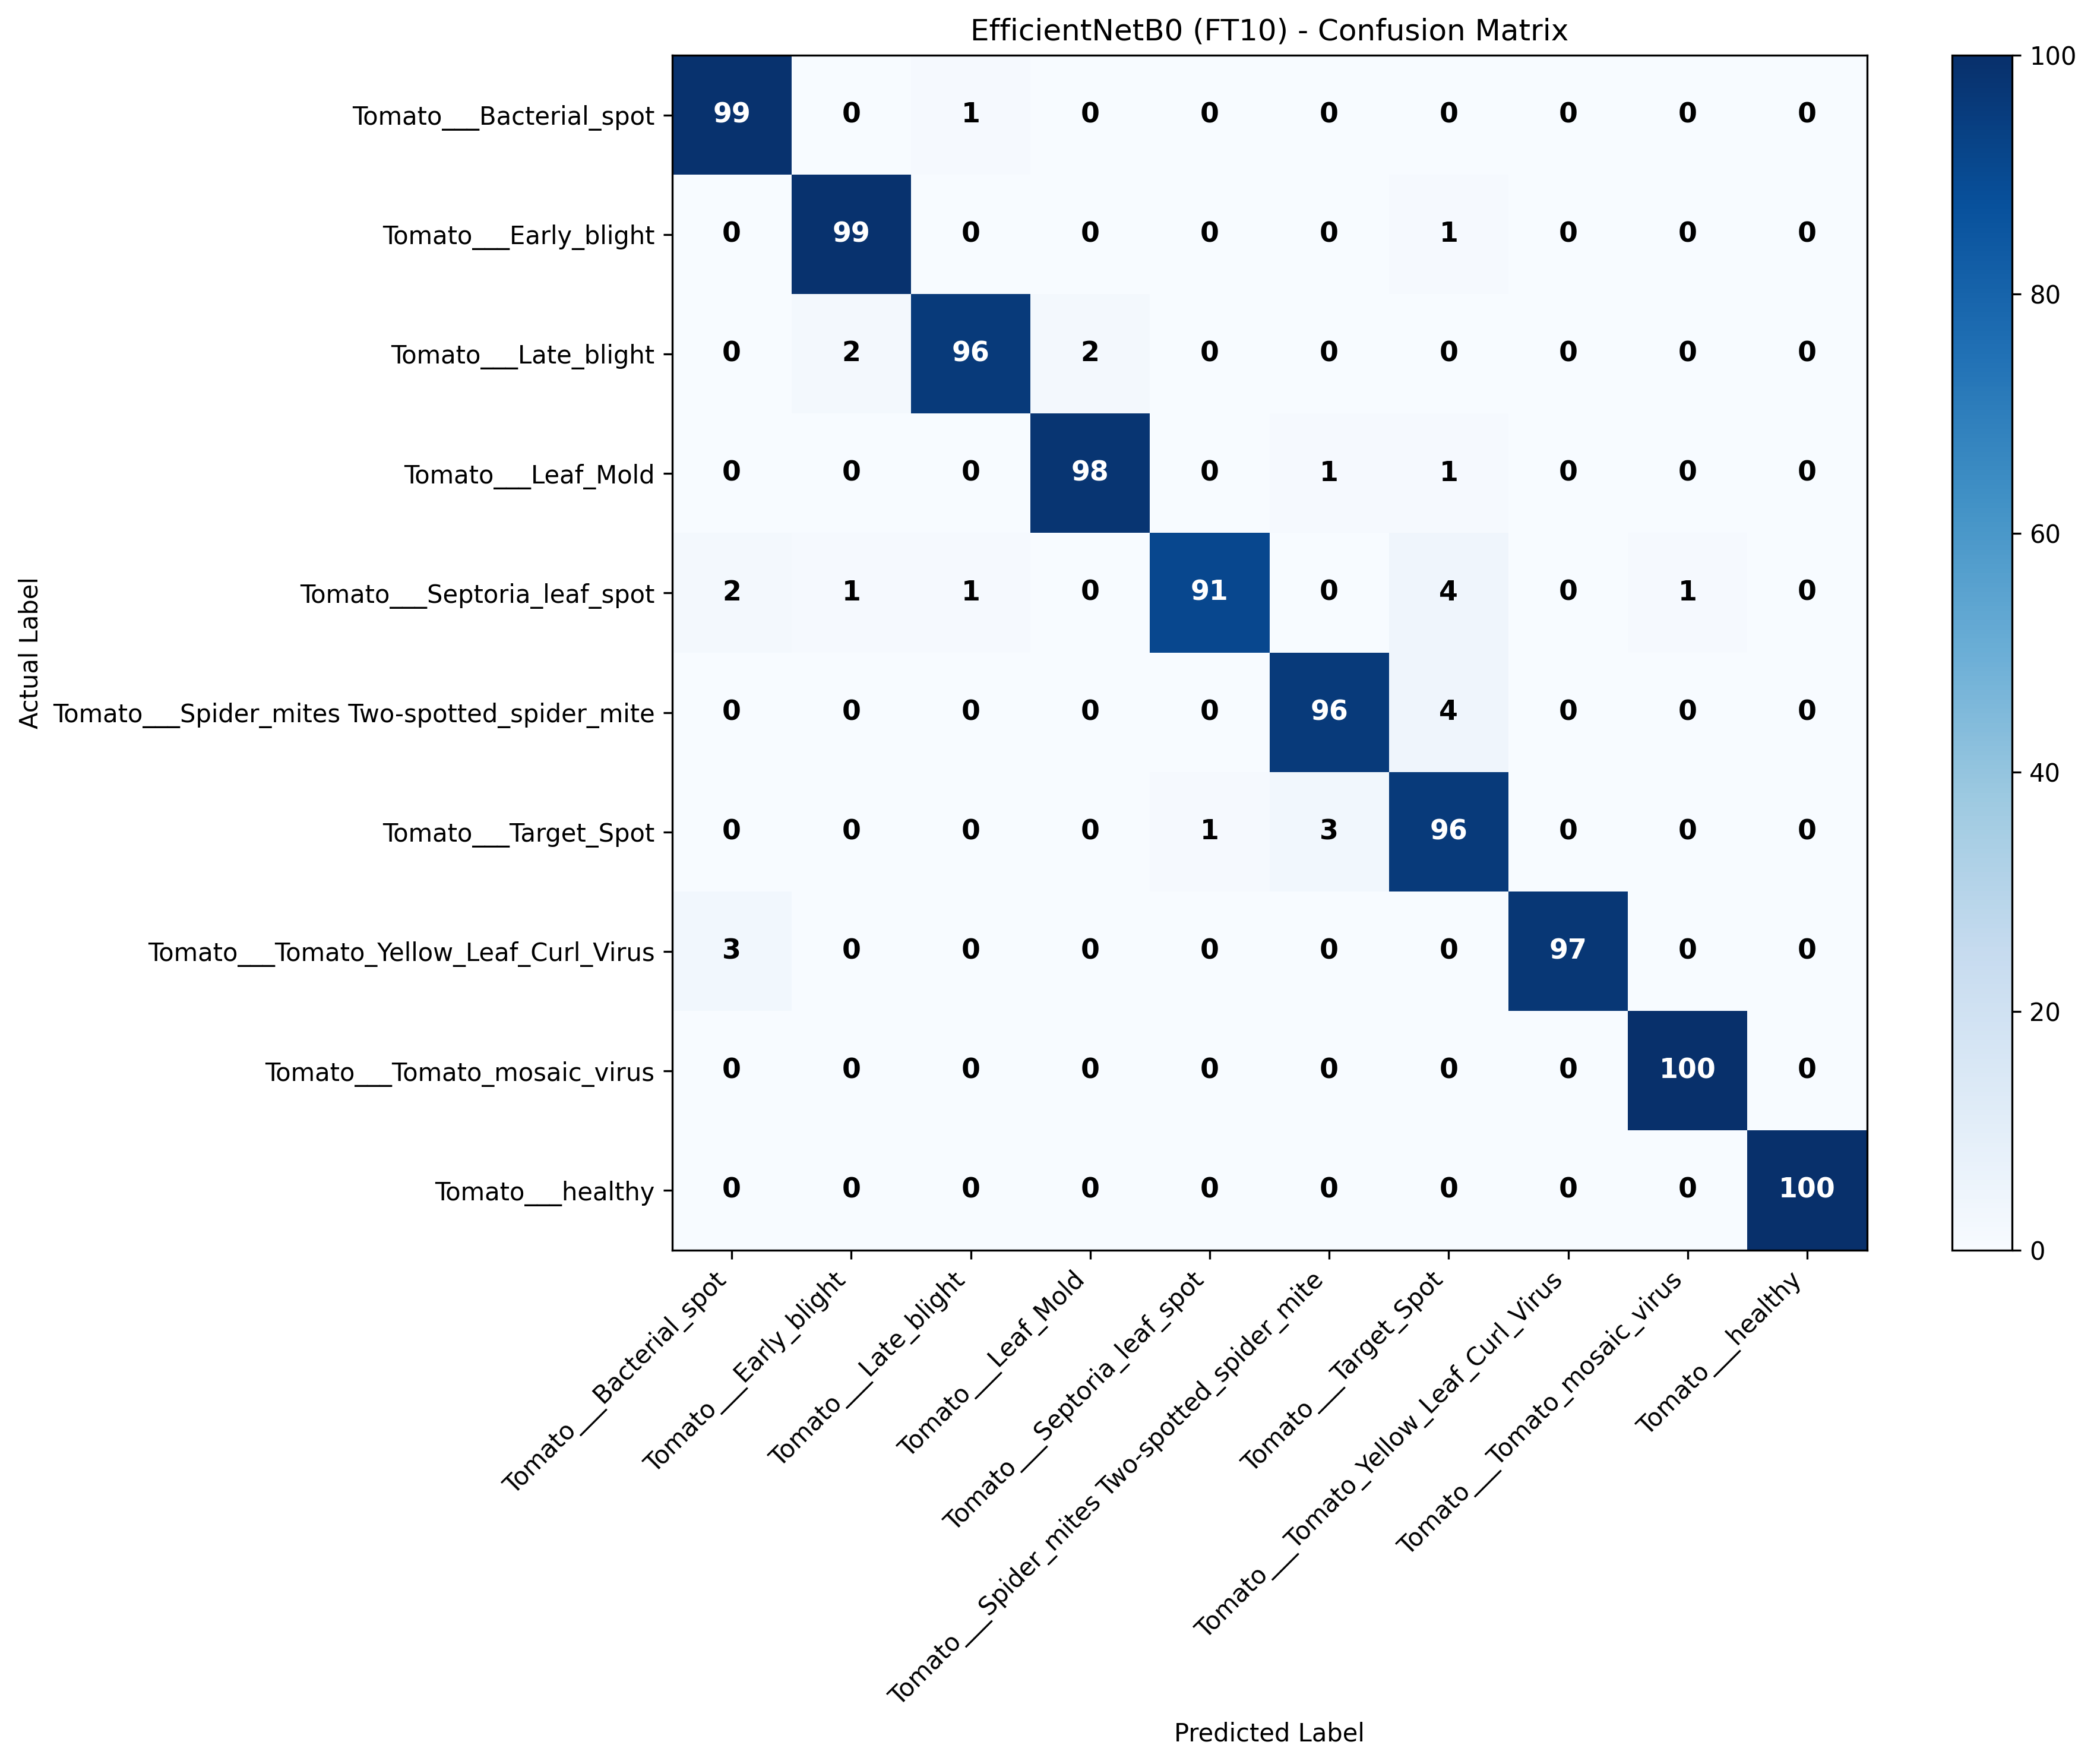

In [21]:
# ============================================
# CELL FT10-3: Eval FT10 (Test set)
# ============================================

ft10_cm, ft10_rep = eval_model(ef_model)

ft10_params = ef_model.count_params()
ft10_size_mb = get_model_size_mb(ef_model)
ft10_inf_mean, ft10_inf_std = inference_ms_per_batch(ef_model, test_ds)

ft10_global = make_global_matrix(
    ft10_rep, ft10_params, ft10_size_mb,
    ft10_inf_mean, ft10_inf_std,
    ft10_train_time
)
ft10_cm_df = make_confusion_table(ft10_cm)

print("=== GLOBAL METRICS: FT10 ===")
display(ft10_global)
display(ft10_cm_df)

plot_confusion_matrix_blue(ft10_cm, class_names, "EfficientNetB0 (FT10) - Confusion Matrix")

In [22]:
# ============================================
# CELL FT10-5: MACs & FLOPs FT10
# ============================================

ft10_macs, ft10_flops = get_macs_and_flops(ef_model)

print("=== EFISIENSI KOMPUTASI (FT10) ===")
print(f"MobileNetV2: MACs = {ft10_macs/1e6:.2f} MMACs | FLOPs = {ft10_flops/1e6:.2f} MFLOPs")

=== EFISIENSI KOMPUTASI (FT10) ===
MobileNetV2: MACs = 400.41 MMACs | FLOPs = 800.81 MFLOPs


In [23]:
# ============================================
# CELL FT10-6: Save FT10 model
# ============================================

EF_FT10_PATH = os.path.join(MODEL_DIR, "efficientnetb0_ft10.keras")
ef_model.save(EF_FT10_PATH, include_optimizer=False)

print("Saved:", EF_FT10_PATH)

Saved: E:\DATASET\MODEL\efficientnetb0_ft10.keras


In [24]:
# ============================================
# CELL FT10-7: Final metric table (FT10)
# ============================================

ft10_epochs_ran = len(ft10_hist["loss"])
ft10_train_time_per_epoch = ft10_train_time / ft10_epochs_ran
ft10_test_ms_per_image = ft10_inf_mean / BATCH_SIZE
ft10_acc = float(ft10_rep["accuracy"])

final_ft10_df = pd.DataFrame({
    "Metric": [
        "Training time/epoch (s)",
        "Testing time/image (ms)",
        "Model size (MB)",
        "FLOPs (MFLOPs)",
        "MACs (MMACs)",
        "Accuracy"
    ],
    "FT10": [
        ft10_train_time_per_epoch,
        ft10_test_ms_per_image,
        ft10_size_mb,
        ft10_flops / 1e6,
        ft10_macs / 1e6,
        ft10_acc
    ]
})

final_ft10_df["FT10"] = final_ft10_df["FT10"].map(fmt)

print("=== HASIL AKHIR FT10 ===")
display(final_ft10_df)

=== HASIL AKHIR FT10 ===


,Metric,FT10
0,Training time/epoch (s),100.4453
1,Testing time/image (ms),11.4669
2,Model size (MB),23.1955
3,FLOPs (MFLOPs),800.8108
4,MACs (MMACs),400.4054
5,Accuracy,0.9720


In [25]:
# ============================================
# CELL FT20-1: Set Fine-tuning FT20 + compile
# - Start dari bobot FE terbaik
# - Unfreeze last N = 20
# - LR lebih kecil dari FT10 (umumnya)
# ============================================

ef_model.set_weights(FE_BEST_WEIGHTS)

FT_LAST_N = 20
LR_STAGE2 = 4e-5

unfrozen = set_trainable_last_n(ef_backbone, last_n=FT_LAST_N)
print("Trainable backbone layers (non-BN) in last N:", unfrozen)

ef_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_STAGE2),
    loss=loss_fn,
    metrics=metrics
)

Trainable backbone layers (non-BN) in last N: 15


In [26]:
# ============================================
# CELL FT20-2: Train FT20
# ============================================

t0 = time.time()
h_ft20 = ef_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks,
    verbose=1
)
t1 = time.time()

ft20_train_time = float(t1 - t0)
ft20_hist = h_ft20.history

print(f"FE train time (s): {fe_train_time}")
print("FE epochs ran:", len(fe_hist["loss"]))

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 119s 395ms/step - acc: 0.9344 - loss: 0.2142 - val_acc: 0.9351 - val_loss: 0.1953
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 104s 370ms/step - acc: 0.9417 - loss: 0.1742 - val_acc: 0.9471 - val_loss: 0.1840
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 103s 364ms/step - acc: 0.9501 - loss: 0.1460 - val_acc: 0.9491 - val_loss: 0.1643
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 103s 366ms/step - acc: 0.9655 - loss: 0.1109 - val_acc: 0.9530 - val_loss: 0.1551
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 103s 365ms/step - acc: 0.9657 - loss: 0.1027 - val_acc: 0.9540 - val_loss: 0.1405
FE train time (s): 1406.4112949371338
FE epochs ran: 15


=== GLOBAL METRICS: FT20 ===


,Metric,Value
0,Accuracy,9.590000e-01
1,Macro Precision,9.592895e-01
2,Macro Recall,9.590000e-01
3,Macro F1,9.589335e-01
4,Weighted F1,9.589335e-01
5,Params,4.062381e+06
6,Model Size (MB),2.665213e+01
7,Inference Mean (ms/batch),3.570811e+02
8,Inference Std (ms/batch),5.470514e-01
9,Train Time (s),5.322355e+02


,Pred_Tomato___Bacterial_spot,Pred_Tomato___Early_blight,Pred_Tomato___Late_blight,Pred_Tomato___Leaf_Mold,Pred_Tomato___Septoria_leaf_spot,Pred_Tomato___Spider_mites Two-spotted_spider_mite,Pred_Tomato___Target_Spot,Pred_Tomato___Tomato_Yellow_Leaf_Curl_Virus,Pred_Tomato___Tomato_mosaic_virus,Pred_Tomato___healthy
Actual_Tomato___Bacterial_spot,99,0,1,0,0,0,0,0,0,0
Actual_Tomato___Early_blight,0,96,1,0,1,0,2,0,0,0
Actual_Tomato___Late_blight,0,4,94,2,0,0,0,0,0,0
Actual_Tomato___Leaf_Mold,0,0,0,96,0,4,0,0,0,0
Actual_Tomato___Septoria_leaf_spot,2,2,1,0,90,0,3,0,2,0
Actual_Tomato___Spider_mites Two-spotted_spider_mite,0,0,0,1,0,94,4,1,0,0
Actual_Tomato___Target_Spot,1,0,0,0,3,3,93,0,0,0
Actual_Tomato___Tomato_Yellow_Leaf_Curl_Virus,3,0,0,0,0,0,0,97,0,0
Actual_Tomato___Tomato_mosaic_virus,0,0,0,0,0,0,0,0,100,0
Actual_Tomato___healthy,0,0,0,0,0,0,0,0,0,100


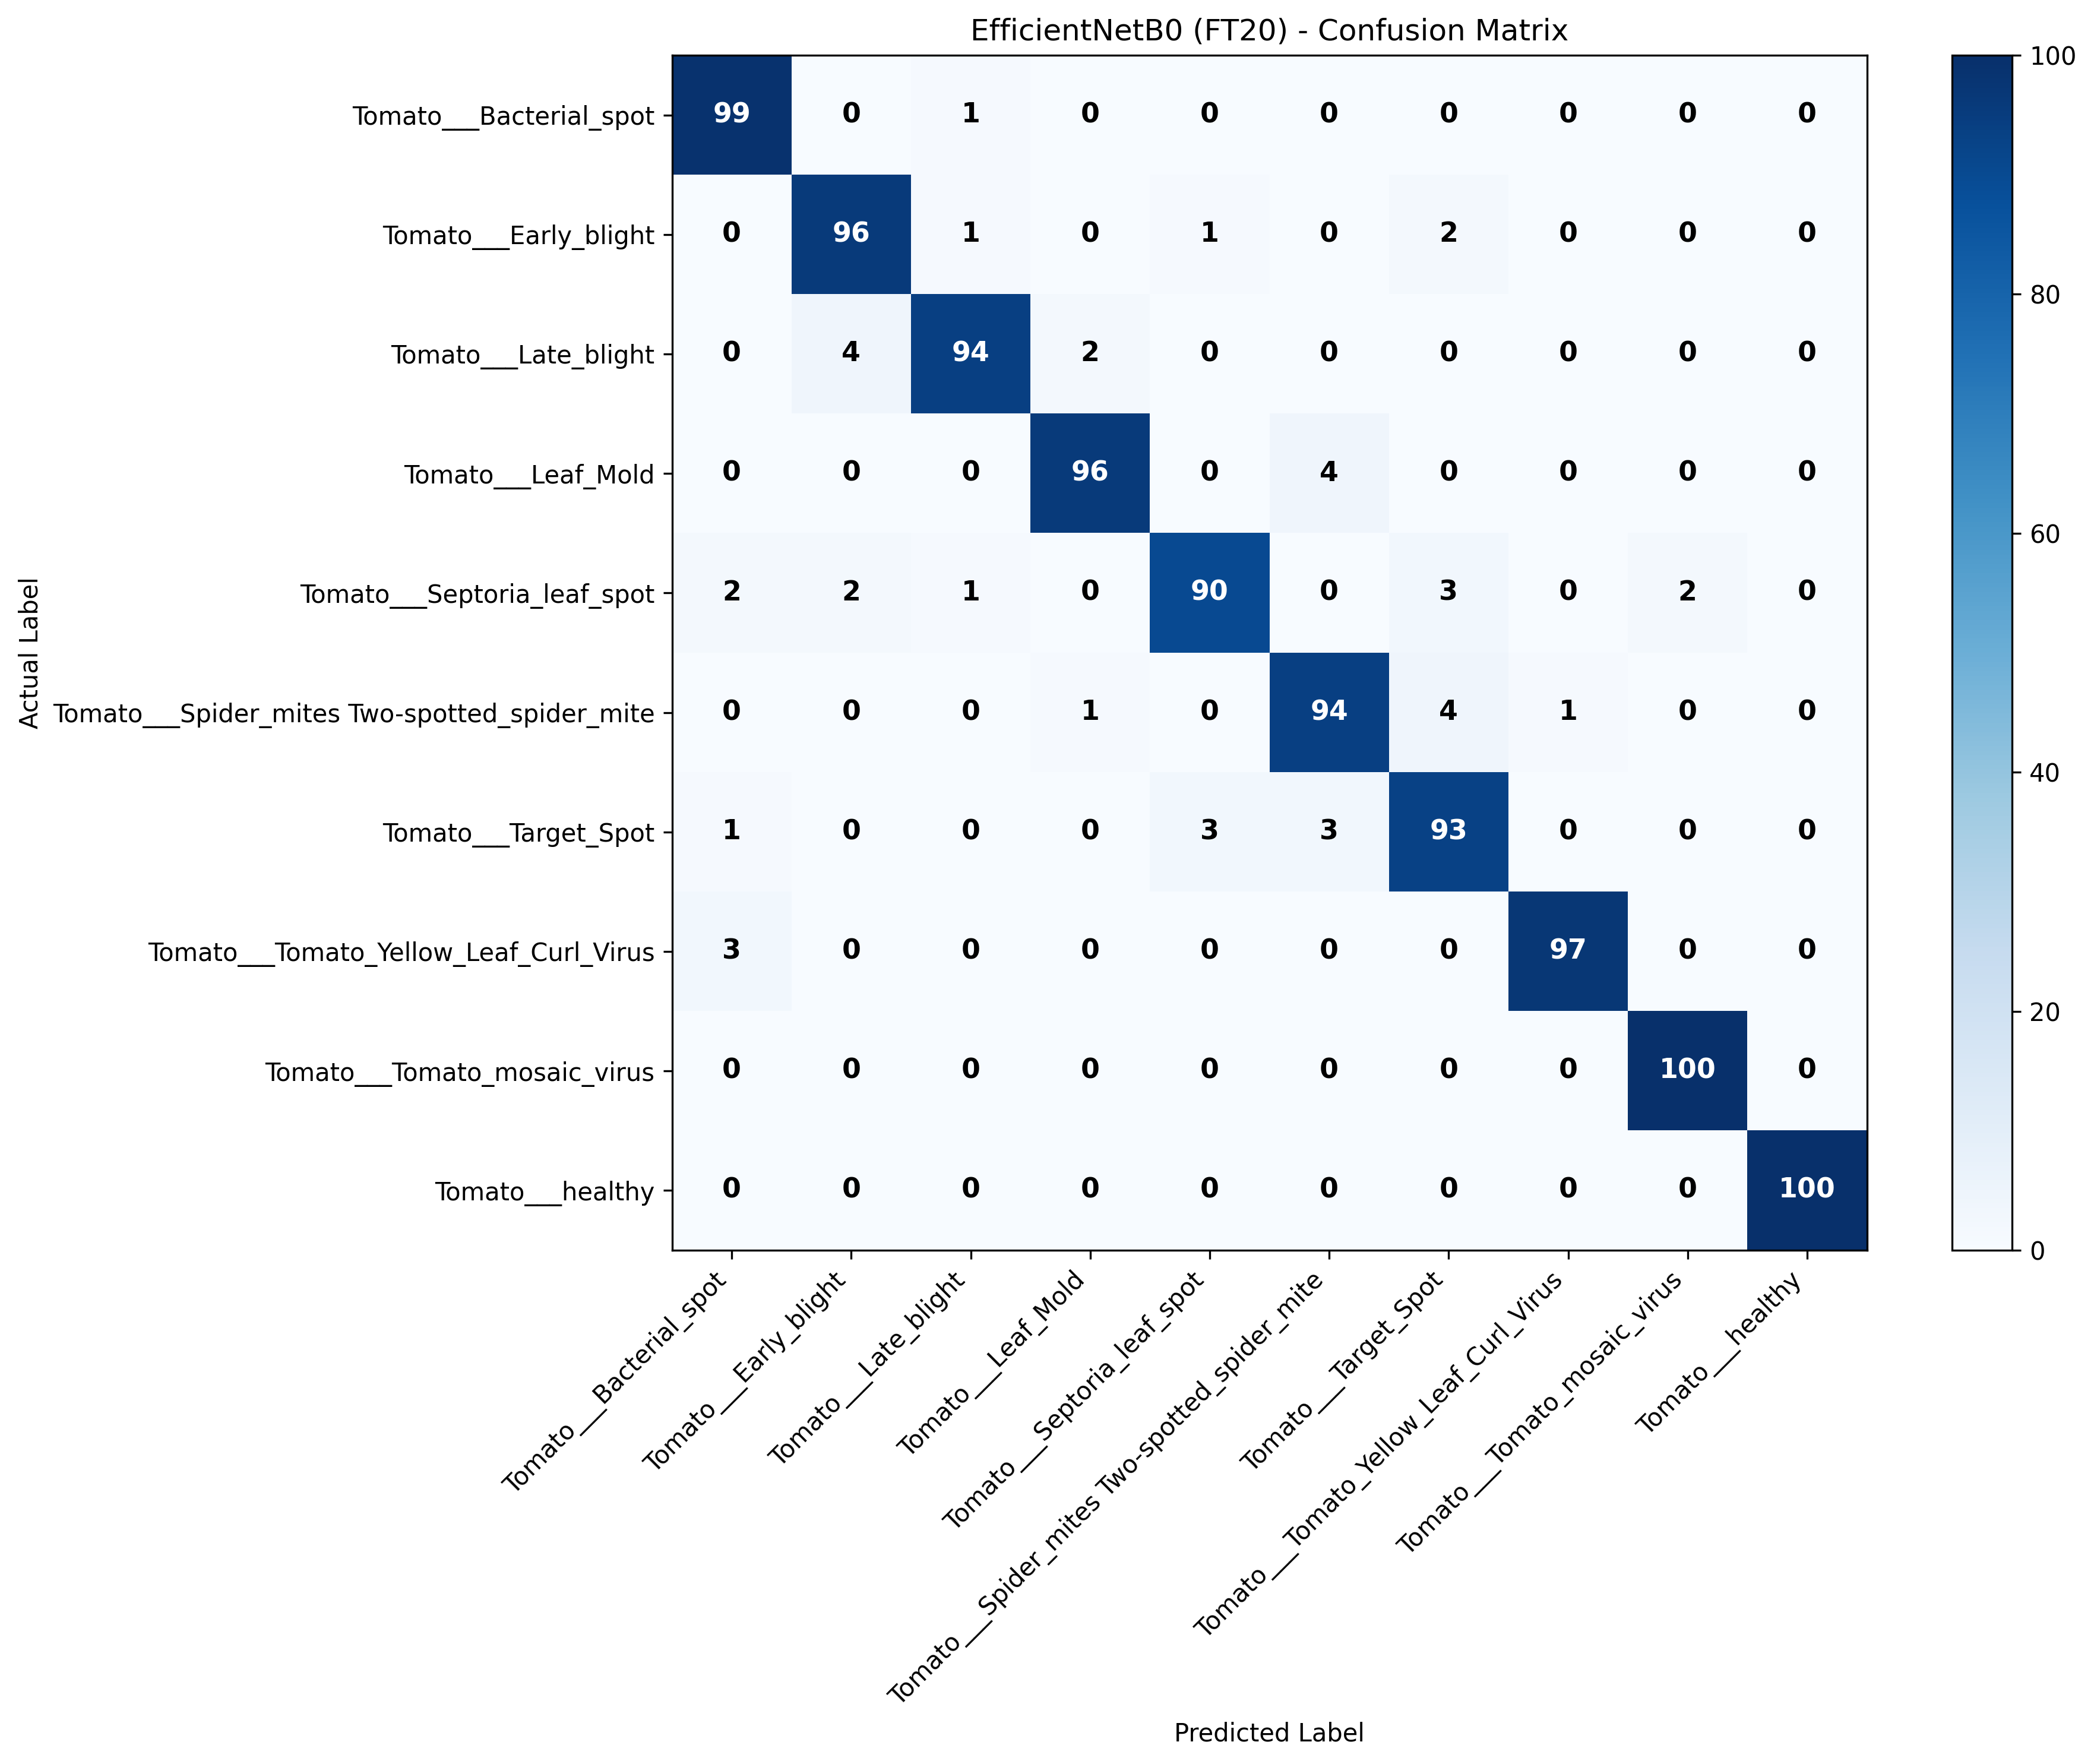

In [27]:
# ============================================
# CELL FT20-3: Eval FT20 (Test set)
# ============================================

ft20_cm, ft20_rep = eval_model(ef_model)

ft20_params = ef_model.count_params()
ft20_size_mb = get_model_size_mb(ef_model)
ft20_inf_mean, ft20_inf_std = inference_ms_per_batch(ef_model, test_ds)

ft20_global = make_global_matrix(
    ft20_rep, ft20_params, ft20_size_mb,
    ft20_inf_mean, ft20_inf_std,
    ft20_train_time
)
ft20_cm_df = make_confusion_table(ft20_cm)

print("=== GLOBAL METRICS: FT20 ===")
display(ft20_global)
display(ft20_cm_df)

plot_confusion_matrix_blue(ft20_cm, class_names, "EfficientNetB0 (FT20) - Confusion Matrix")

In [28]:
# ============================================
# CELL FT20-5: MACs & FLOPs FT20
# ============================================

ft20_macs, ft20_flops = get_macs_and_flops(ef_model)

print("=== EFISIENSI KOMPUTASI (FT20) ===")
print(f"MobileNetV2: MACs = {ft20_macs/1e6:.2f} MMACs | FLOPs = {ft20_flops/1e6:.2f} MFLOPs")

=== EFISIENSI KOMPUTASI (FT20) ===
MobileNetV2: MACs = 400.41 MMACs | FLOPs = 800.81 MFLOPs


In [29]:
# ============================================
# CELL FT20-6: Save FT20 model
# ============================================

EF_FT20_PATH = os.path.join(MODEL_DIR, "efficientnetb0_ft20.keras")
ef_model.save(EF_FT20_PATH, include_optimizer=False)

print("Saved:", EF_FT20_PATH)

Saved: E:\DATASET\MODEL\efficientnetb0_ft20.keras


In [30]:
# ============================================
# CELL FT20-7: Final metric table (FT20)
# ============================================

ft20_epochs_ran = len(ft20_hist["loss"])
ft20_train_time_per_epoch = ft20_train_time / ft20_epochs_ran
ft20_test_ms_per_image = ft20_inf_mean / BATCH_SIZE
ft20_acc = float(ft20_rep["accuracy"])

final_ft20_df = pd.DataFrame({
    "Metric": [
        "Training time/epoch (s)",
        "Testing time/image (ms)",
        "Model size (MB)",
        "FLOPs (MFLOPs)",
        "MACs (MMACs)",
        "Accuracy"
    ],
    "FT20": [
        ft20_train_time_per_epoch,
        ft20_test_ms_per_image,
        ft20_size_mb,
        ft20_flops / 1e6,
        ft20_macs / 1e6,
        ft20_acc
    ]
})

final_ft20_df["FT20"] = final_ft20_df["FT20"].map(fmt)

print("=== HASIL AKHIR FT20 ===")
display(final_ft20_df)

=== HASIL AKHIR FT20 ===


,Metric,FT20
0,Training time/epoch (s),106.4471
1,Testing time/image (ms),11.1588
2,Model size (MB),26.6521
3,FLOPs (MFLOPs),800.8108
4,MACs (MMACs),400.4054
5,Accuracy,0.9590


In [31]:
# ============================================
# CELL FT30-1: Set Fine-tuning FT30 + compile
# - Start dari bobot FE terbaik
# - Unfreeze last N = 30
# - LR lebih kecil dari FT20 (umumnya)
# ============================================

ef_model.set_weights(FE_BEST_WEIGHTS)

FT_LAST_N = 30
LR_STAGE2 = 8e-6

unfrozen = set_trainable_last_n(ef_backbone, last_n=FT_LAST_N)
print("Trainable backbone layers (non-BN) in last N:", unfrozen)

ef_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_STAGE2),
    loss=loss_fn,
    metrics=metrics
)

Trainable backbone layers (non-BN) in last N: 23


In [32]:
# ============================================
# CELL FT30-2: Train FT30
# ============================================

t0 = time.time()
h_ft30 = ef_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks,
    verbose=1
)
t1 = time.time()

ft30_train_time = float(t1 - t0)
ft30_hist = h_ft30.history

print(f"FE train time (s): {fe_train_time}")
print("FE epochs ran:", len(fe_hist["loss"]))

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 119s 395ms/step - acc: 0.9238 - loss: 0.2434 - val_acc: 0.9261 - val_loss: 0.2206
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 107s 381ms/step - acc: 0.9288 - loss: 0.2113 - val_acc: 0.9321 - val_loss: 0.2078
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 106s 376ms/step - acc: 0.9310 - loss: 0.2036 - val_acc: 0.9341 - val_loss: 0.2011
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 106s 378ms/step - acc: 0.9393 - loss: 0.1848 - val_acc: 0.9381 - val_loss: 0.1942
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 107s 378ms/step - acc: 0.9446 - loss: 0.1736 - val_acc: 0.9421 - val_loss: 0.1908
FE train time (s): 1406.4112949371338
FE epochs ran: 15


=== GLOBAL METRICS: FT30 ===


,Metric,Value
0,Accuracy,9.530000e-01
1,Macro Precision,9.533389e-01
2,Macro Recall,9.530000e-01
3,Macro F1,9.527332e-01
4,Weighted F1,9.527332e-01
5,Params,4.062381e+06
6,Model Size (MB),2.772797e+01
7,Inference Mean (ms/batch),3.671775e+02
8,Inference Std (ms/batch),7.614374e+00
9,Train Time (s),5.457130e+02


,Pred_Tomato___Bacterial_spot,Pred_Tomato___Early_blight,Pred_Tomato___Late_blight,Pred_Tomato___Leaf_Mold,Pred_Tomato___Septoria_leaf_spot,Pred_Tomato___Spider_mites Two-spotted_spider_mite,Pred_Tomato___Target_Spot,Pred_Tomato___Tomato_Yellow_Leaf_Curl_Virus,Pred_Tomato___Tomato_mosaic_virus,Pred_Tomato___healthy
Actual_Tomato___Bacterial_spot,99,0,1,0,0,0,0,0,0,0
Actual_Tomato___Early_blight,0,94,2,0,1,0,2,0,0,1
Actual_Tomato___Late_blight,0,3,96,1,0,0,0,0,0,0
Actual_Tomato___Leaf_Mold,0,0,0,96,0,4,0,0,0,0
Actual_Tomato___Septoria_leaf_spot,3,2,1,3,85,0,4,0,2,0
Actual_Tomato___Spider_mites Two-spotted_spider_mite,0,0,0,1,0,94,4,1,0,0
Actual_Tomato___Target_Spot,1,0,0,0,3,3,93,0,0,0
Actual_Tomato___Tomato_Yellow_Leaf_Curl_Virus,3,0,0,0,0,0,0,97,0,0
Actual_Tomato___Tomato_mosaic_virus,0,0,0,1,0,0,0,0,99,0
Actual_Tomato___healthy,0,0,0,0,0,0,0,0,0,100


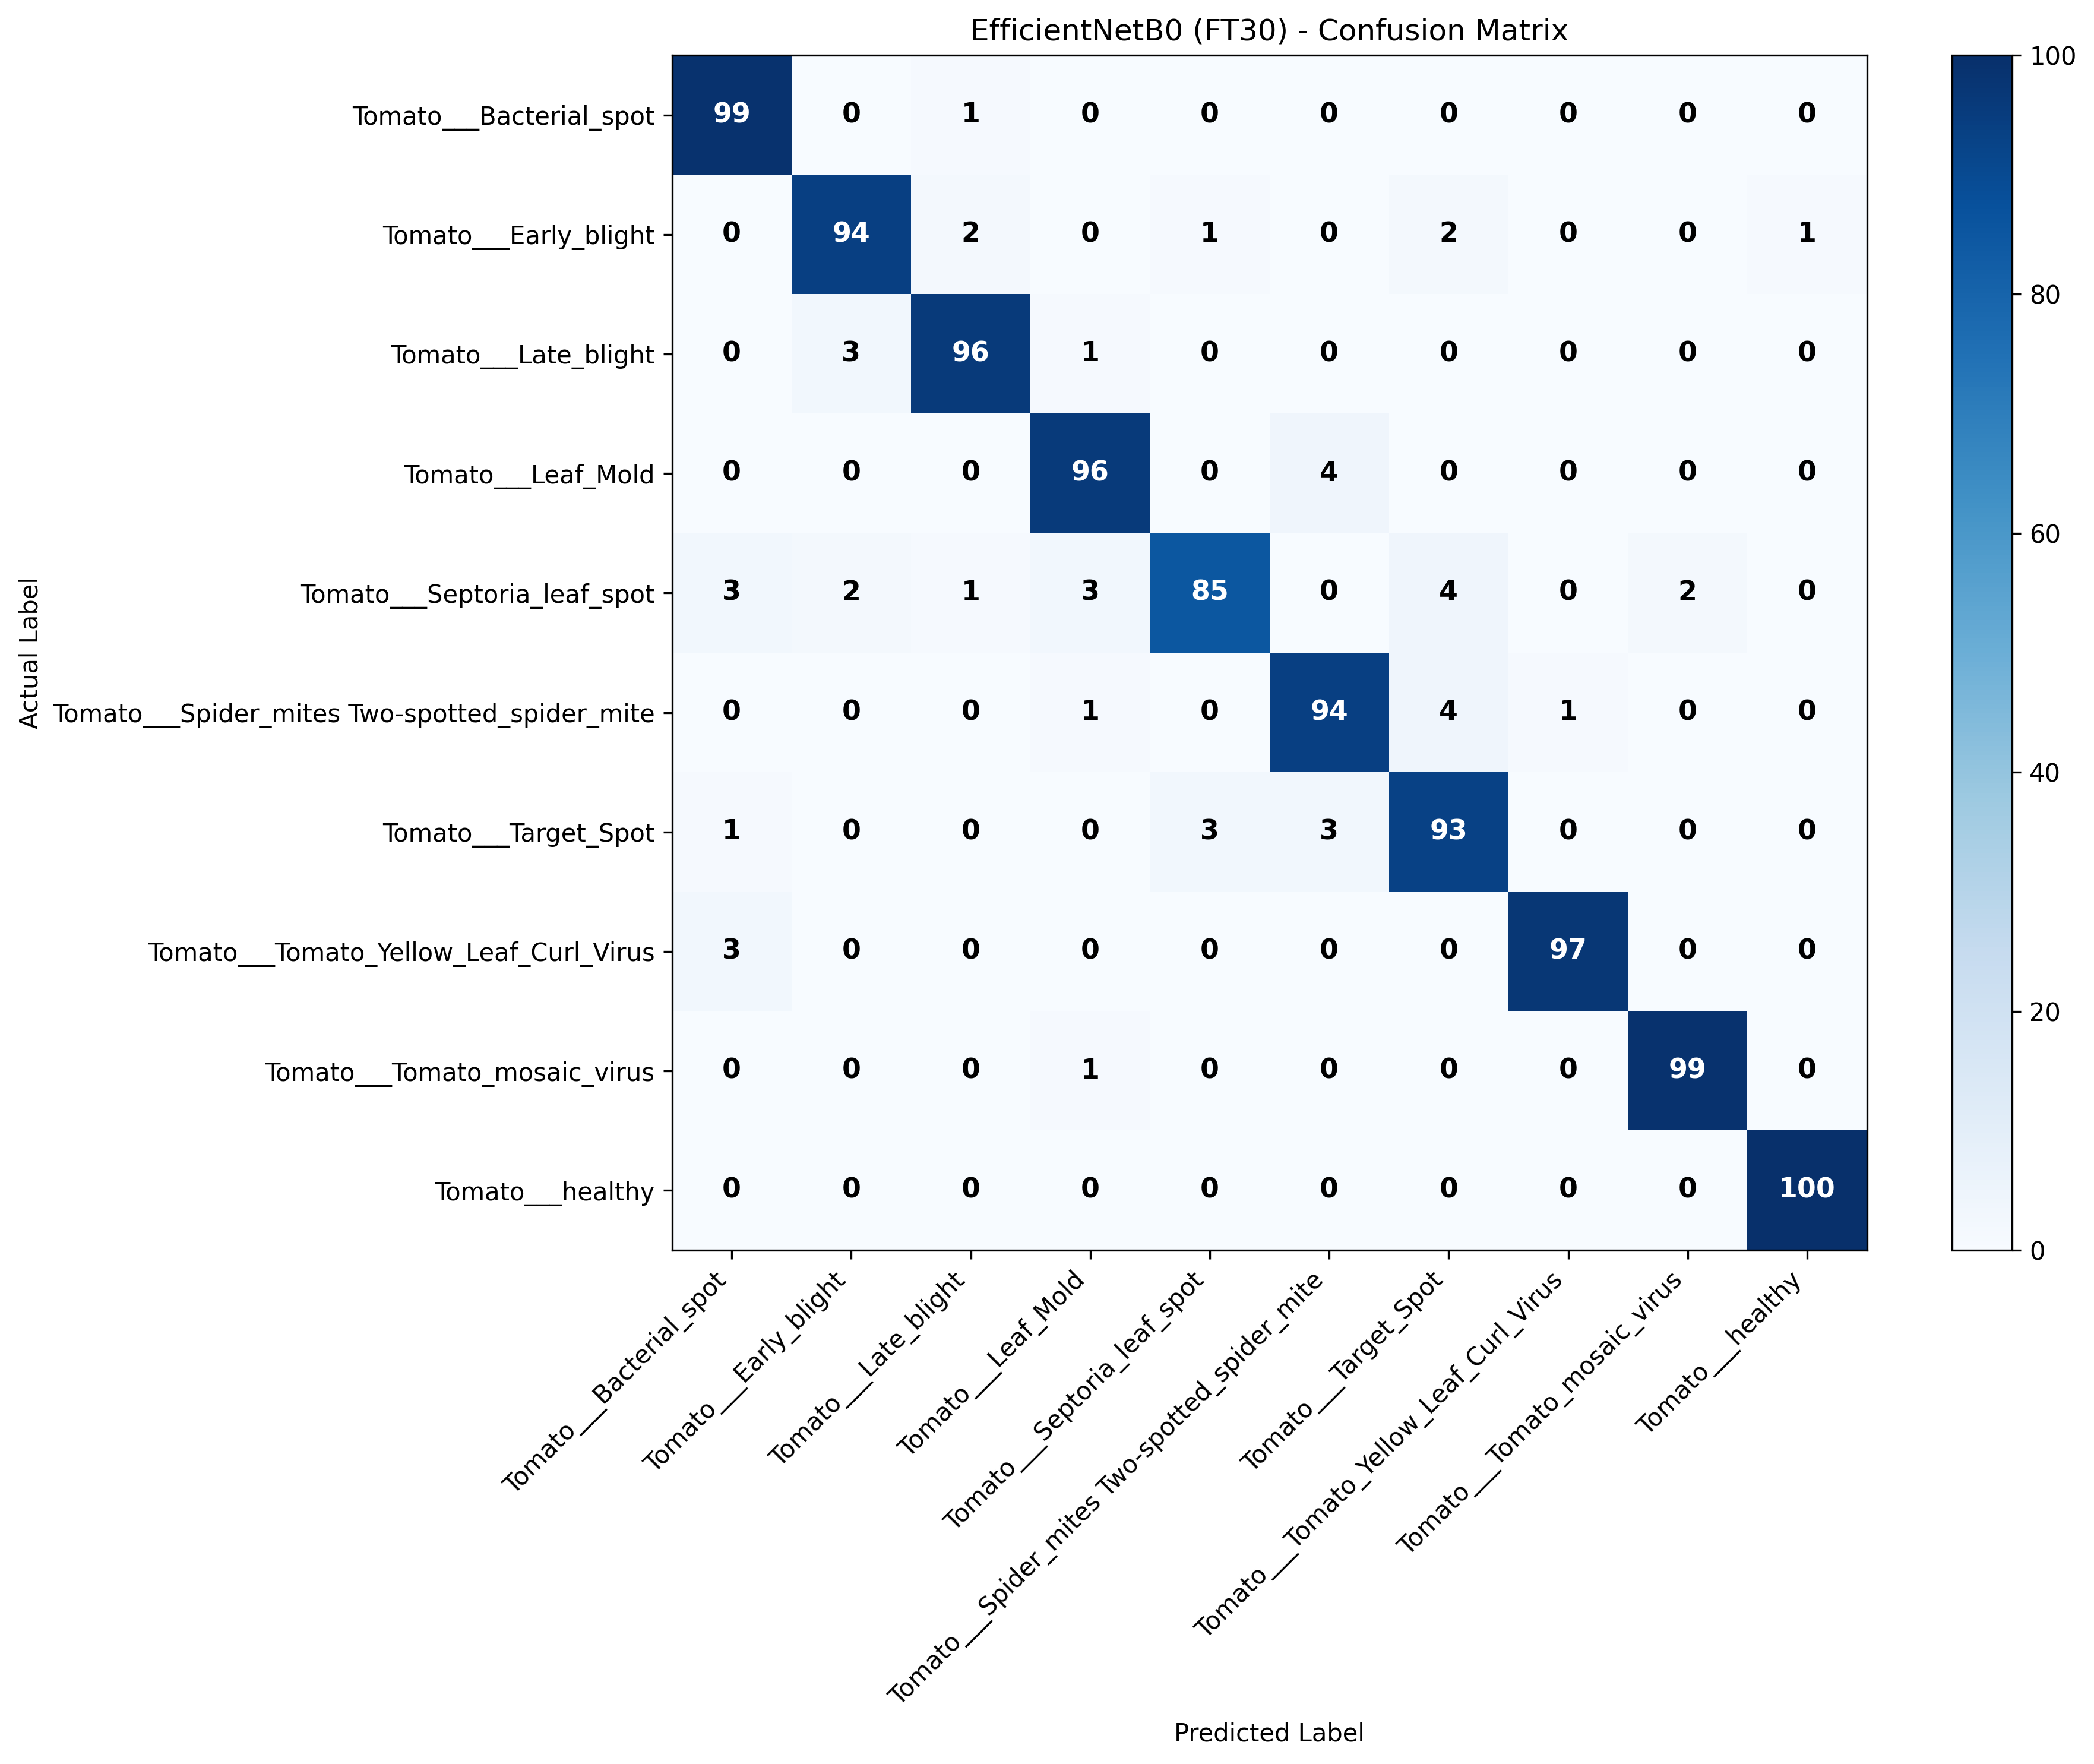

In [33]:
# ============================================
# CELL FT30-3: Eval FT30 (Test set)
# ============================================

ft30_cm, ft30_rep = eval_model(ef_model)

ft30_params = ef_model.count_params()
ft30_size_mb = get_model_size_mb(ef_model)
ft30_inf_mean, ft30_inf_std = inference_ms_per_batch(ef_model, test_ds)

ft30_global = make_global_matrix(
    ft30_rep, ft30_params, ft30_size_mb,
    ft30_inf_mean, ft30_inf_std,
    ft30_train_time
)
ft30_cm_df = make_confusion_table(ft30_cm)

print("=== GLOBAL METRICS: FT30 ===")
display(ft30_global)
display(ft30_cm_df)

plot_confusion_matrix_blue(ft30_cm, class_names, "EfficientNetB0 (FT30) - Confusion Matrix")

In [34]:
# ============================================
# CELL FT30-5: MACs & FLOPs FT30
# ============================================

ft30_macs, ft30_flops = get_macs_and_flops(ef_model)

print("=== EFISIENSI KOMPUTASI (FT30) ===")
print(f"MobileNetV2: MACs = {ft30_macs/1e6:.2f} MMACs | FLOPs = {ft30_flops/1e6:.2f} MFLOPs")

=== EFISIENSI KOMPUTASI (FT30) ===
MobileNetV2: MACs = 400.41 MMACs | FLOPs = 800.81 MFLOPs


In [35]:
# ============================================
# CELL FT30-6: Save FT30 model
# ============================================

EF_FT30_PATH = os.path.join(MODEL_DIR, "effiecientnetb0_ft30.keras")
ef_model.save(EF_FT30_PATH, include_optimizer=False)

print("Saved:", EF_FT30_PATH)

Saved: E:\DATASET\MODEL\effiecientnetb0_ft30.keras


In [36]:
# ============================================
# CELL FT30-7: Final metric table (FT30)
# ============================================

ft30_epochs_ran = len(ft30_hist["loss"])
ft30_train_time_per_epoch = ft30_train_time / ft30_epochs_ran
ft30_test_ms_per_image = ft30_inf_mean / BATCH_SIZE
ft30_acc = float(ft30_rep["accuracy"])

final_ft30_df = pd.DataFrame({
    "Metric": [
        "Training time/epoch (s)",
        "Testing time/image (ms)",
        "Model size (MB)",
        "FLOPs (MFLOPs)",
        "MACs (MMACs)",
        "Accuracy"
    ],
    "FT30": [
        ft30_train_time_per_epoch,
        ft30_test_ms_per_image,
        ft30_size_mb,
        ft30_flops / 1e6,
        ft30_macs / 1e6,
        ft30_acc
    ]
})

final_ft30_df["FT30"] = final_ft30_df["FT30"].map(fmt)

print("=== HASIL AKHIR FT30 ===")
display(final_ft30_df)

=== HASIL AKHIR FT30 ===


,Metric,FT30
0,Training time/epoch (s),109.1426
1,Testing time/image (ms),11.4743
2,Model size (MB),27.7280
3,FLOPs (MFLOPs),800.8108
4,MACs (MMACs),400.4054
5,Accuracy,0.9530


In [37]:
# ============================================
# CELL SUMMARY-1: Gabungkan semua final metric jadi 1 tabel
# ============================================

# Gabungkan FE, FT10, FT20, FT30 jadi satu tabel (join by Metric)
final_all = final_fe_df.merge(final_ft10_df, on="Metric", how="left") \
                       .merge(final_ft20_df, on="Metric", how="left") \
                       .merge(final_ft30_df, on="Metric", how="left")

print("=== FINAL TABLE (FE vs FT10 vs FT20 vs FT30) ===")
display(final_all)

=== FINAL TABLE (FE vs FT10 vs FT20 vs FT30) ===


,Metric,FE,FT10,FT20,FT30
0,Training time/epoch (s),93.7608,100.4453,106.4471,109.1426
1,Testing time/image (ms),11.4709,11.4669,11.1588,11.4743
2,Model size (MB),16.4012,23.1955,26.6521,27.7280
3,FLOPs (MFLOPs),800.8108,800.8108,800.8108,800.8108
4,MACs (MMACs),400.4054,400.4054,400.4054,400.4054
5,Accuracy,0.9430,0.9720,0.9590,0.9530


In [38]:
# ============================================
# CELL SUMMARY-2: Tabel average semua varian (per metric)
# - Contoh: average model size, average accuracy, average avg-robust, dst.
# ============================================

avg_table = final_all.copy()

# kolom numeric = semua selain "Metric"
num_cols = [c for c in avg_table.columns if c != "Metric"]

# konversi kembali ke float (karena sudah diformat string 4 desimal)
for c in num_cols:
    avg_table[c] = avg_table[c].astype(float)

avg_vals = avg_table[num_cols].mean(axis=1)  # rata-rata per baris metric
avg_result = pd.DataFrame({
    "Metric": avg_table["Metric"],
    "AVG_ALL": avg_vals
})

# format 4 desimal
avg_result["AVG_ALL"] = avg_result["AVG_ALL"].map(lambda x: f"{x:.4f}")

print("=== AVERAGE SEMUA VARIAN (AVG_ALL) ===")
display(avg_result)

# Optional: tampilkan final_all + avg_all berdampingan (merge)
final_with_avg = final_all.merge(avg_result, on="Metric", how="left")
display(final_with_avg)

=== AVERAGE SEMUA VARIAN (AVG_ALL) ===


,Metric,AVG_ALL
0,Training time/epoch (s),102.4489
1,Testing time/image (ms),11.3927
2,Model size (MB),23.4942
3,FLOPs (MFLOPs),800.8108
4,MACs (MMACs),400.4054
5,Accuracy,0.9567


,Metric,FE,FT10,FT20,FT30,AVG_ALL
0,Training time/epoch (s),93.7608,100.4453,106.4471,109.1426,102.4489
1,Testing time/image (ms),11.4709,11.4669,11.1588,11.4743,11.3927
2,Model size (MB),16.4012,23.1955,26.6521,27.7280,23.4942
3,FLOPs (MFLOPs),800.8108,800.8108,800.8108,800.8108,800.8108
4,MACs (MMACs),400.4054,400.4054,400.4054,400.4054,400.4054
5,Accuracy,0.9430,0.9720,0.9590,0.9530,0.9567


In [39]:
# ============================================
# CELL COMB-FE-FT: Gabungan FE + FT dengan batas FT
# ============================================

def plot_fe_ft_combined(
    fe_hist,
    ft_hist,
    fe_epochs,
    title,
    ft_label="Fine-Tuning"
):
    # ---- Ambil key acc ----
    acc_key = "acc" if "acc" in fe_hist else "categorical_accuracy"
    val_acc_key = "val_acc" if "val_acc" in fe_hist else "val_categorical_accuracy"

    # ---- Gabung history ----
    train_acc = fe_hist[acc_key] + ft_hist[acc_key]
    val_acc   = fe_hist[val_acc_key] + ft_hist[val_acc_key]

    train_loss = fe_hist["loss"] + ft_hist["loss"]
    val_loss   = fe_hist["val_loss"] + ft_hist["val_loss"]

    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(14,5))

    # ===== Accuracy =====
    plt.subplot(1,2,1)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, val_acc, label="Val Acc")

    plt.axvline(
        x=fe_epochs,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Start Fine-Tuning"
    )

    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # ===== Loss =====
    plt.subplot(1,2,2)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")

    plt.axvline(
        x=fe_epochs,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Start Fine-Tuning"
    )

    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

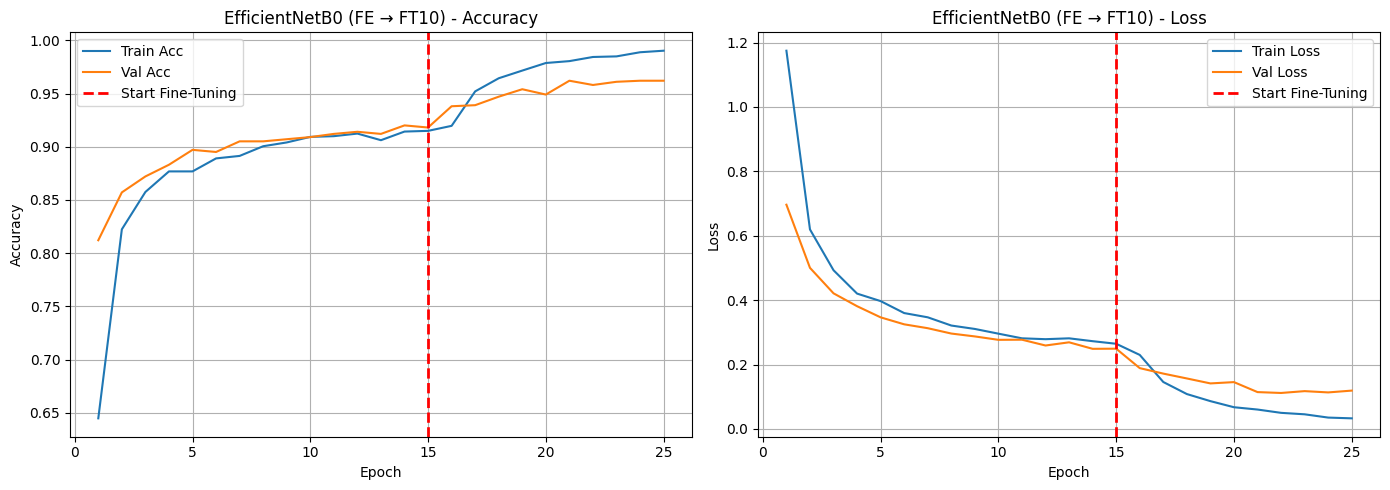

In [40]:
plot_fe_ft_combined(
    fe_hist=fe_hist,
    ft_hist=ft10_hist,
    fe_epochs=len(fe_hist["loss"]),
    title="EfficientNetB0 (FE → FT10)"
)

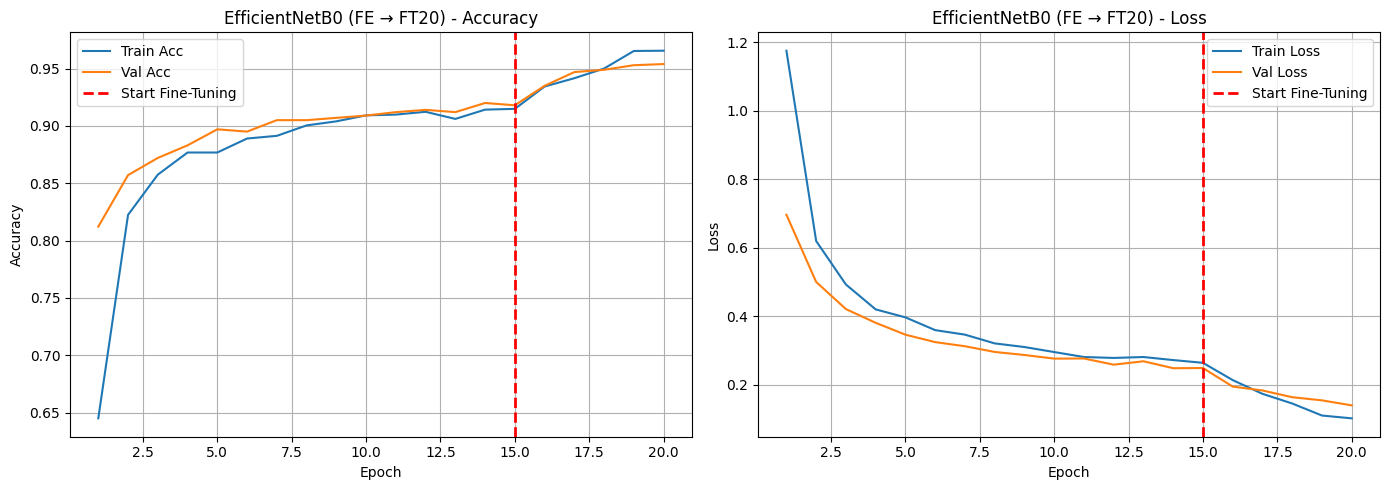

In [41]:
plot_fe_ft_combined(
    fe_hist=fe_hist,
    ft_hist=ft20_hist,
    fe_epochs=len(fe_hist["loss"]),
    title="EfficientNetB0 (FE → FT20)"
)

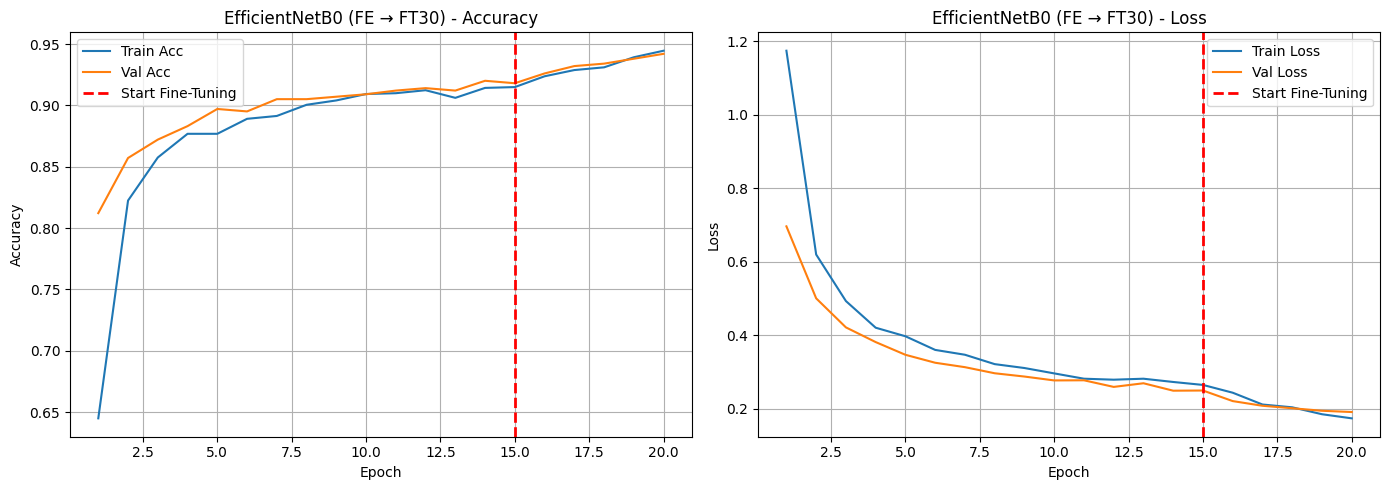

In [42]:
plot_fe_ft_combined(
    fe_hist=fe_hist,
    ft_hist=ft30_hist,
    fe_epochs=len(fe_hist["loss"]),
    title="EfficientNetB0 (FE → FT30)"
)